# Normalization and Convex Optimization Investigation

In this notebook, we will explore the non-negativity of f constraint and its affect on the optimal solution. Also we want to see if we can normalize in such a way that keeps the comparative analysis of cell cycling genes valid.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [244]:
# Example of a deconvolution with negative f values in the solution

/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/cvxpy/problems/problem.py:1403: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


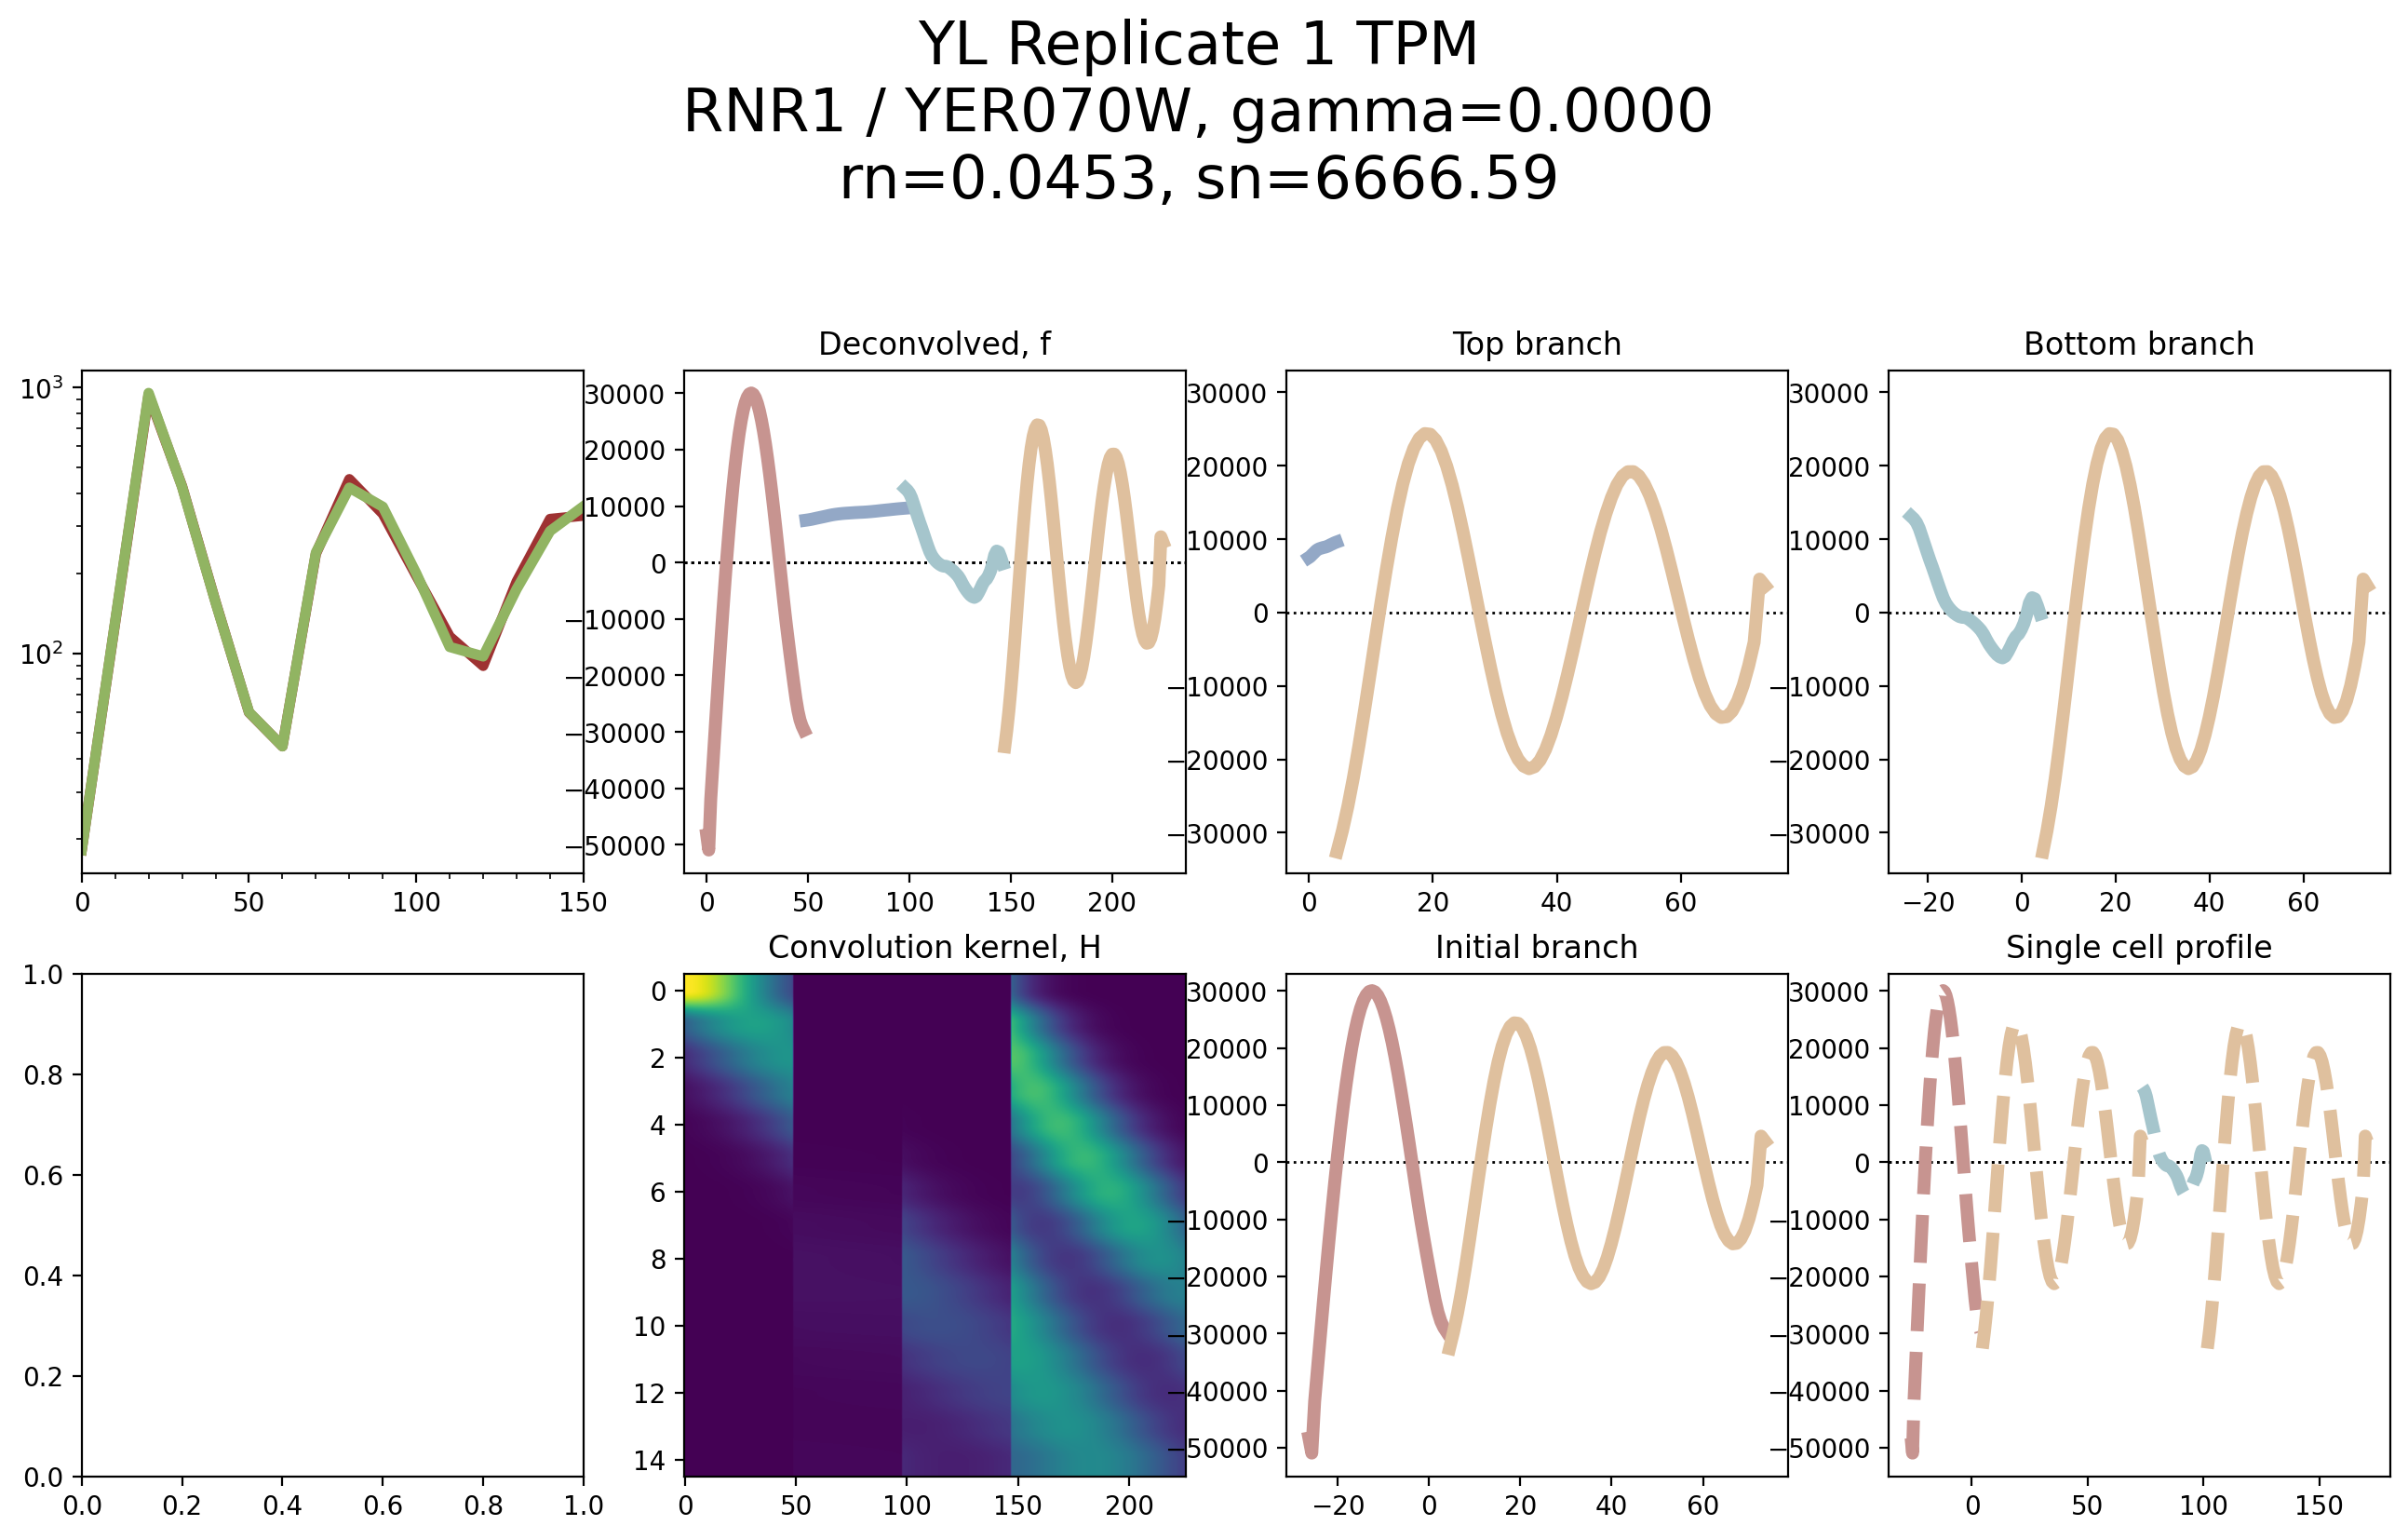

In [146]:
tpm_config = load_yl_replicate1_rg1_TPM_config()
tpm_model = Model(config=tpm_config, gamma=0.0, gene_or_orfname='RNR1')
tpm_model.deconvolve(enforce_non_negative=False)
tpm_model.plot_deconvolved_gene()

In [289]:
def custom_normalization(tpm_model):
    """
    Attempting a normalization scheme based on the min and max values of the gene.
    
    TODO: This is just a proof of concept as we work out the reasoning behind,
    the need to scale with this method and constant.
    """
    
    def _normalize(g):
        min_val, max_val = g.min(), g.max()
        diff = max_val-min_val
        translation = 1
        g = (g-min_val) / diff + 2
        return g
    
    tpm_model.g = tpm_model.g1 = _normalize(tpm_model.g)


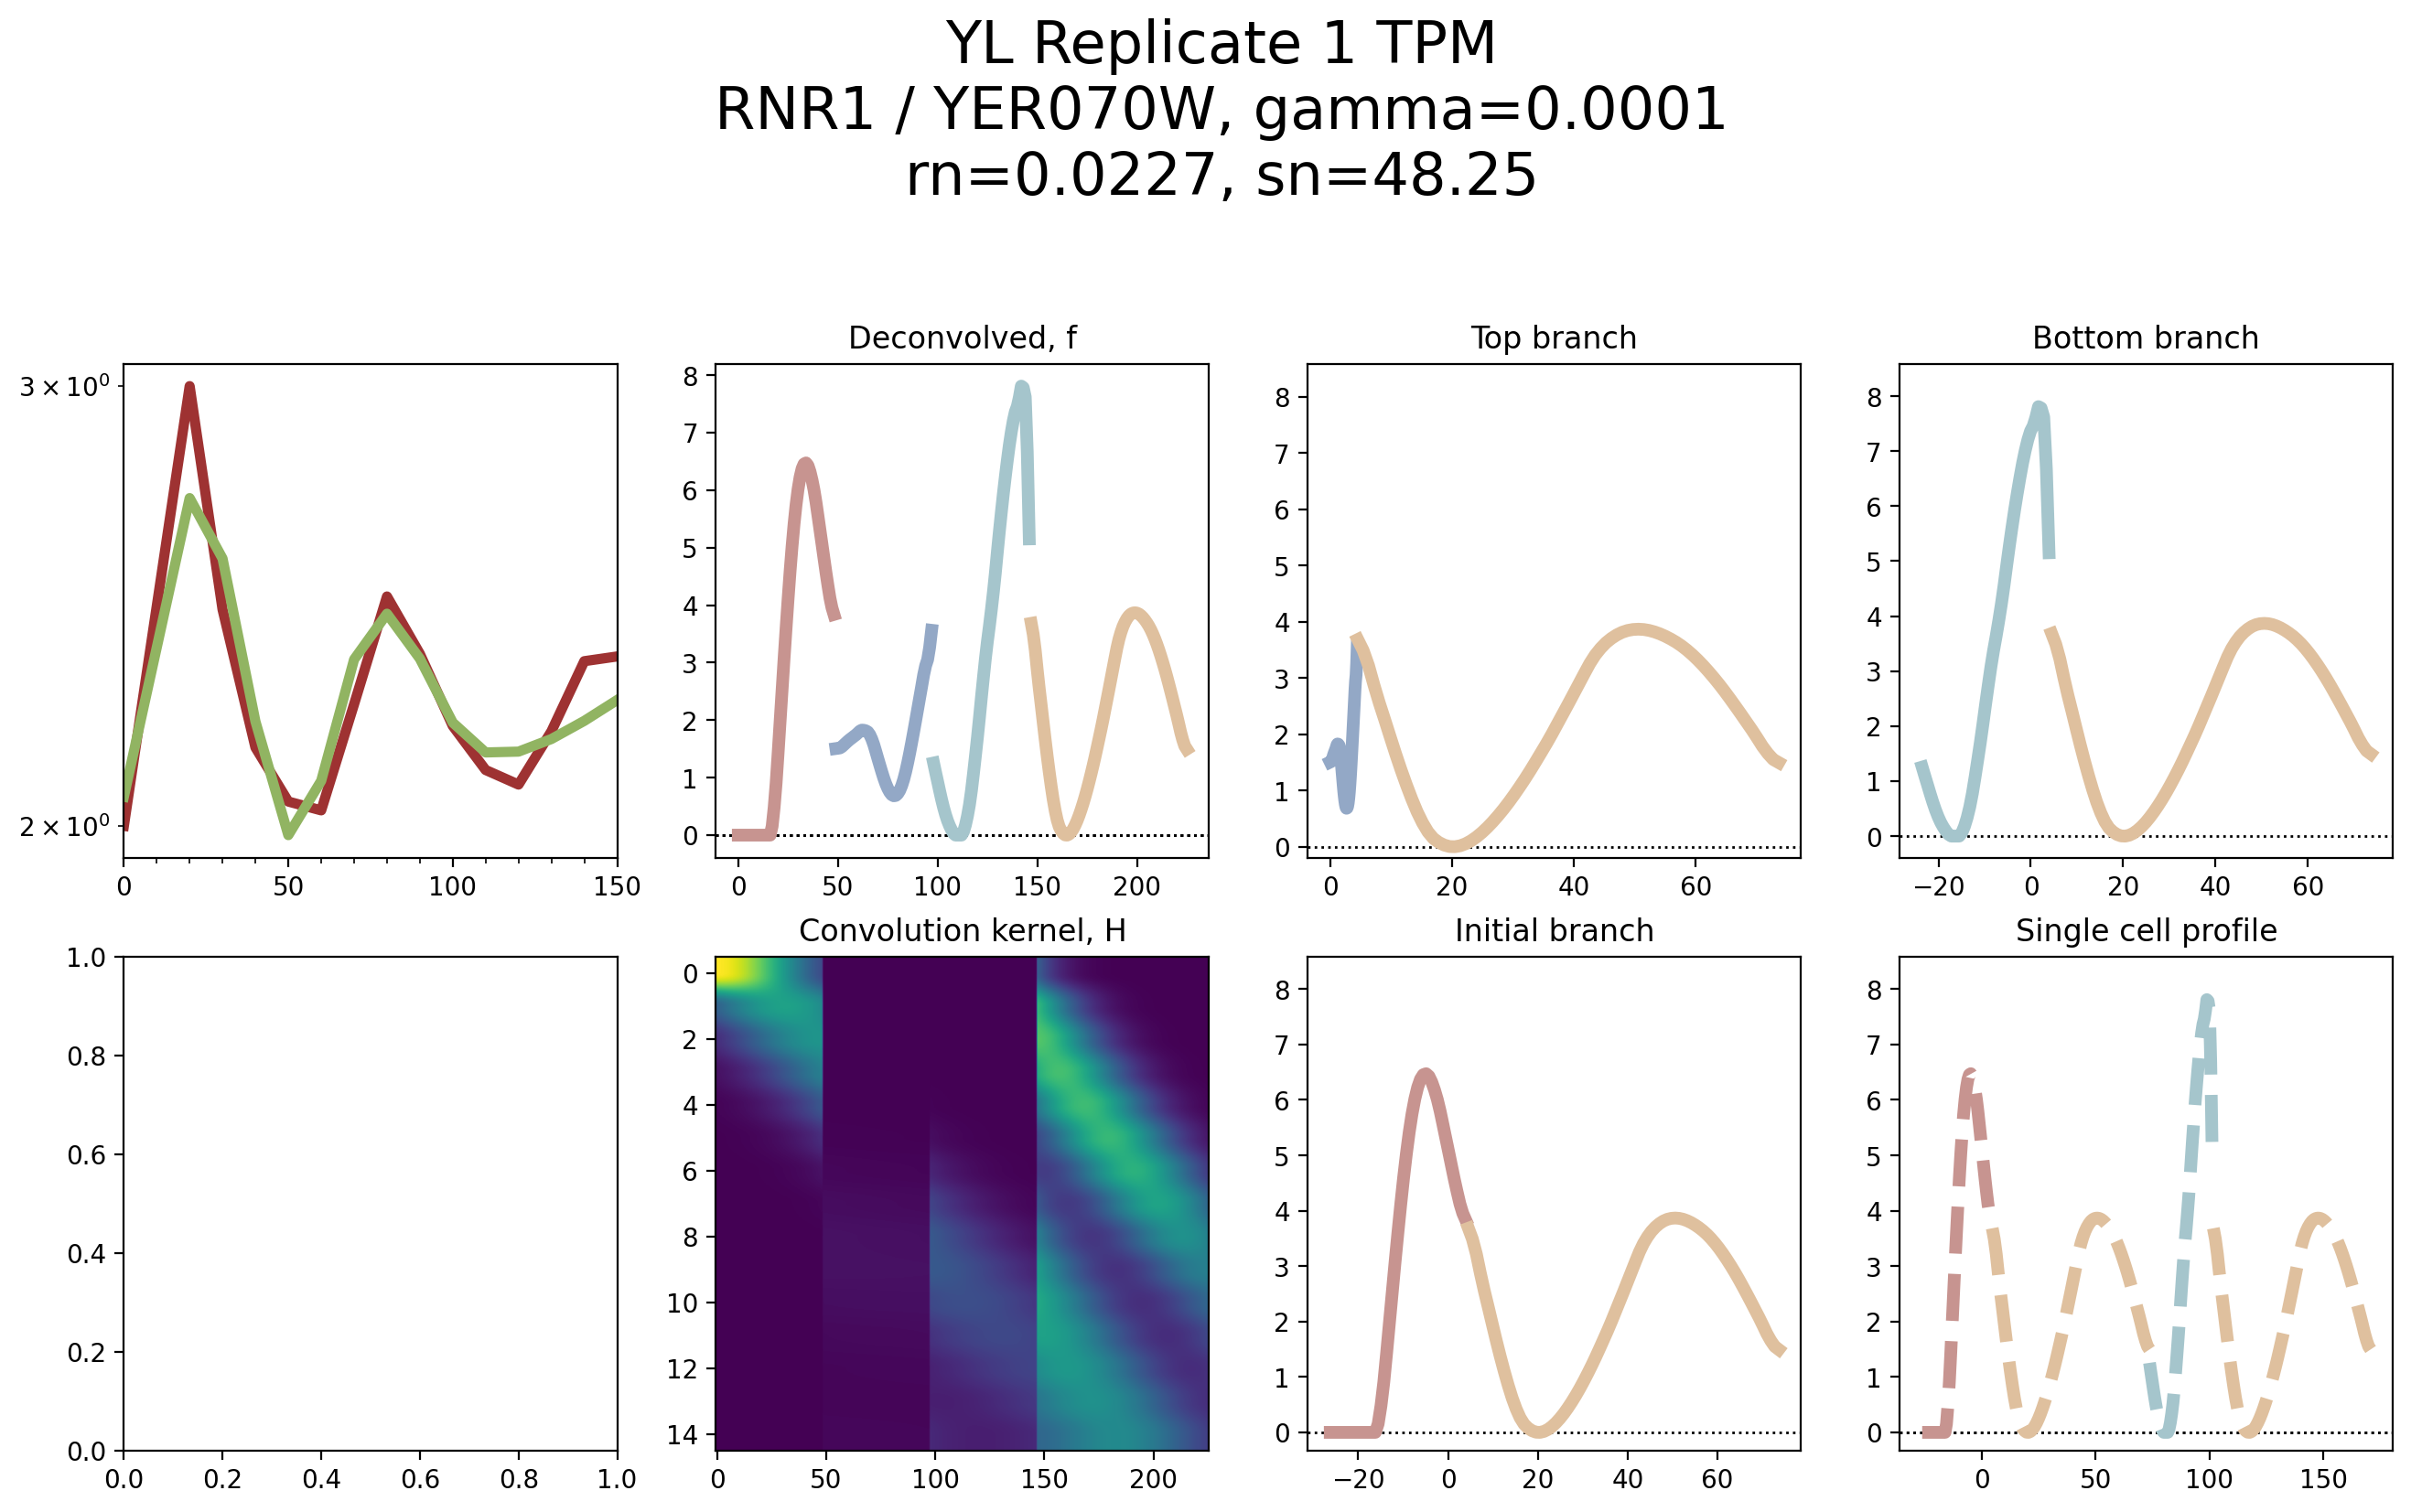

In [294]:
tpm_config = load_yl_replicate1_rg1_TPM_config()
tpm_model = Model(config=tpm_config, gamma=0.0001, gene_or_orfname='RNR1')

# Custom normalization to try and handle the negative values, 
custom_normalization(tpm_model)

tpm_model.deconvolve(enforce_non_negative=True)
tpm_model.plot_deconvolved_gene()

In [292]:

# tpm_config = load_yl_replicate1_rg1_TPM_config()
# tpm_model = Model(config=tpm_config, gamma=0.0004, gene_or_orfname='CLB2')

# # Custom normalization to try and handle the negative values, 
# custom_normalization(tpm_model)

# tpm_model.deconvolve(enforce_non_negative=True)
# tpm_model.plot_deconvolved_gene()